# Esrimasi Spektrum Seismik Gunung Berapi


# Analsis PSD+Spectogram


Text(0, 0.5, 'Amplitudo')

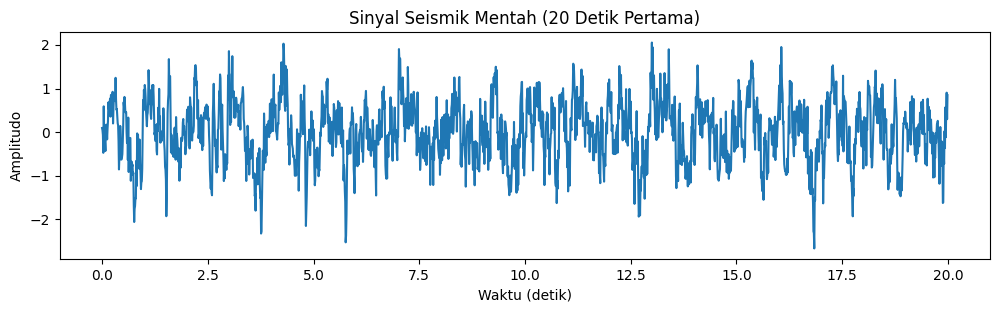

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 100 # Frekuensi sampling (Hz)
durasi = 300 # Detik
t = np.arange(0, durasi, 1/fs)
np.random.seed(88) # Seed sesuai permintaan

# Kita buat sinyal sintetis yang merepresentasikan aktivitas vulkanik
def generate_signal(t, f_range, amplitude):
    f_low, f_high = f_range
    # Menggunakan noise yang difilter untuk mensimulasikan gelombang seismik alami
    b, a = signal.butter(4, [f_low, f_high], btype='bandpass', fs=fs)
    raw_noise = np.random.normal(0, 1, len(t))
    return signal.lfilter(b, a, raw_noise) * amplitude

# Komponen Sinyal
s_wave = generate_signal(t, [0.1, 1], 1.5)
p_wave = generate_signal(t, [1, 10], 1.0)
tremor = generate_signal(t, [0.5, 5], 0.8)

# Komponen Noise
noise_angin = np.random.normal(0, 0.3, len(t)) # Broadband sigma = 0.3
noise_mikroseismik = 0.4 * np.sin(2 * np.pi * 1 * t) # 1 Hz (kendaraan)
noise_pln = 0.2 * np.sin(2 * np.pi * 50 * t) # 50 Hz (Interferensi Listrik)

# Total Sinyal Gabungan
y = s_wave + p_wave + tremor + noise_angin + noise_mikroseismik + noise_pln

# 3. Analisis PSD menggunakan Metode Welch (Gambar 2)
# nperseg = 1024 sesuai instruksi
freqs_welch, psd_welch = signal.welch(y, fs, nperseg=1024)

# 4. Analisis Spektrogram / STFT (Gambar 2)
# nperseg = 256 sesuai instruksi
f_stft, t_stft, Sxx = signal.spectrogram(y, fs, nperseg=256)

# 5. Visualisasi
plt.figure(figsize=(12, 10))

# Plot Sinyal Waktu
plt.subplot(3, 1, 1)
plt.plot(t[:2000], y[:2000]) # Plot 20 detik pertama agar terlihat jelas
plt.title('Sinyal Seismik Mentah (20 Detik Pertama)')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')

# High-Pass 0.1 Hz

C:\Users\Dzuumirrah\AppData\Local\Temp\ipykernel_24888\1109205666.py:38: UserWarning: The filter's denominator is extremely small at frequencies [0.000, 0.001, 0.003, 0.003, 0.004, 0.005, 0.009], around which a singularity may be present
  _, gd = signal.group_delay((b, a), w=8000)


N_transient : 488 sampel
t_transient : 4.9 detik
Data terbuang: 1.6%


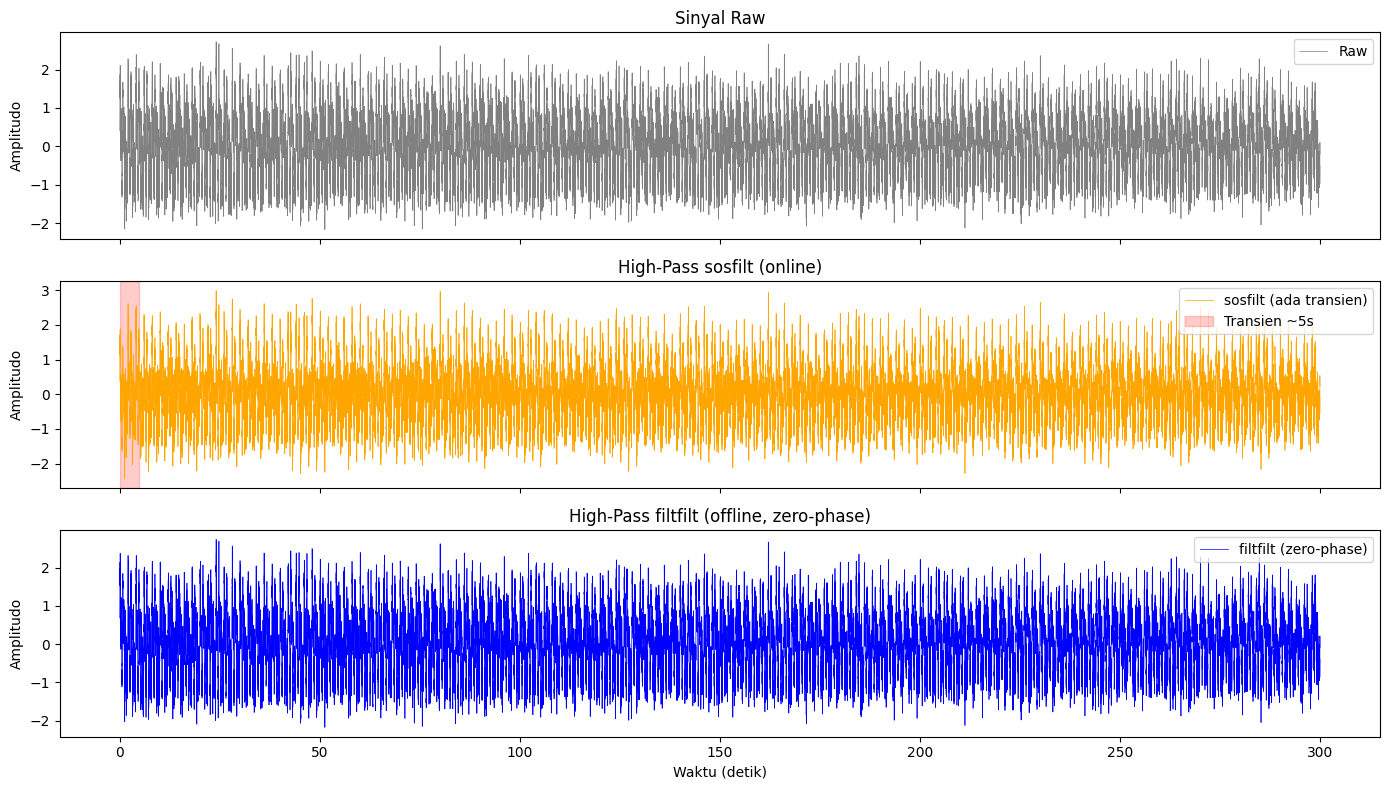

Plot tersimpan!


In [3]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# ============================================================
# SETUP SINYAL (dari Starter Code Topik 8)
# ============================================================
fs = 100.
np.random.seed(88)
N = int(fs * 300)
t = np.arange(N) / fs

# Sinyal seismik
x_P      = 0.80 * np.sin(2*np.pi*3.0*t) * np.exp(-0.002*t)   # P-wave 3 Hz
x_S      = 0.50 * np.sin(2*np.pi*0.5*t)                        # S-wave 0.5 Hz
x_tremor = 0.60 * np.sin(2*np.pi*1.5*t) * (1 + 0.3*np.sin(2*np.pi*0.05*t))
x_signal = x_P + x_S + x_tremor

# Noise
x_micro  = 0.40 * np.sin(2*np.pi*1.0*t + 1.2)
x_wind   = 0.30 * np.random.randn(N)
x_pln    = 0.20 * np.sin(2*np.pi*50*t)
x_noise  = x_micro + x_wind + x_pln
x_raw    = x_signal + x_noise

# ============================================================
# HIGH-PASS FILTER 0.1 Hz — Butterworth Orde 4
# ============================================================
fc    = 0.1          # Hz
order = 4
fn    = fc / (fs/2)  # normalized = 0.002

b, a = signal.butter(order, fn, btype='high')

# Estimasi N_transient
w, h = signal.freqz(b, a, worN=8000)
# Gunakan group delay untuk estimasi transien
_, gd = signal.group_delay((b, a), w=8000)
N_transient = int(np.max(gd))
t_transient = N_transient / fs

print(f"N_transient : {N_transient} sampel")
print(f"t_transient : {t_transient:.1f} detik")
print(f"Data terbuang: {t_transient/300*100:.1f}%")

# Filter: sosfilt (lebih stabil numerik) vs filtfilt
sos = signal.butter(order, fn, btype='high', output='sos')

# sosfilt — ada transien
x_hp_sosfilt = signal.sosfilt(sos, x_raw)

# filtfilt — zero-phase, transien minimal
b2, a2 = signal.butter(order, fn, btype='high')
x_hp_filtfilt = signal.filtfilt(b2, a2, x_raw)

# ============================================================
# PLOT PERBANDINGAN
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t, x_raw, color='gray', lw=0.5, label='Raw')
axes[0].set_ylabel('Amplitudo'); axes[0].set_title('Sinyal Raw')
axes[0].legend()

axes[1].plot(t, x_hp_sosfilt, color='orange', lw=0.5, label='sosfilt (ada transien)')
axes[1].axvspan(0, t_transient, alpha=0.2, color='red', label=f'Transien ~{t_transient:.0f}s')
axes[1].set_ylabel('Amplitudo'); axes[1].set_title('High-Pass sosfilt (online)')
axes[1].legend()

axes[2].plot(t, x_hp_filtfilt, color='blue', lw=0.5, label='filtfilt (zero-phase)')
axes[2].set_ylabel('Amplitudo'); axes[2].set_title('High-Pass filtfilt (offline, zero-phase)')
axes[2].set_xlabel('Waktu (detik)'); axes[2].legend()

plt.tight_layout()
plt.savefig('highpass_comparison.png', dpi=150)
plt.show()
print("Plot tersimpan!")

# Low-Pass 15 Hz(Anti-Aliasing + Signal Isolation)

--- Analisis Penapis ---
Jenis: Low-Pass Butterworth Orde 6
Frekuensi Potong (fc): 15 Hz
Atenuasi pada 50 Hz (PLN): -479.98 dB


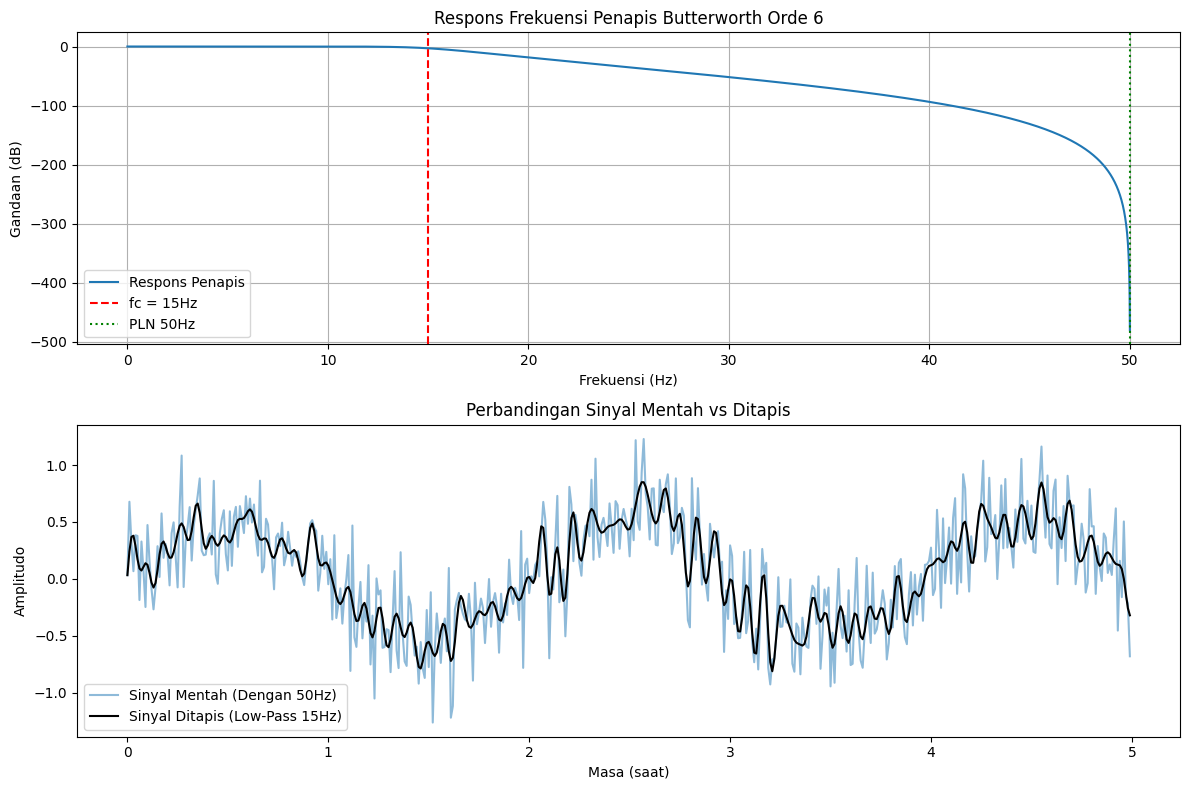

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 100          # Frekuensi pensampelan (Hz)
durasi = 300      # 5 minit
t = np.arange(0, durasi, 1/fs)
np.random.seed(88) # Seed ditetapkan kepada 88

# Komponen frekuensi rendah (P, S, Tremor)
s_wave = 0.5 * np.sin(2 * np.pi * 0.5 * t)
# Noise PLN 50 Hz (Gangguan Elektrik)
noise_pln = 0.2 * np.sin(2 * np.pi * 50 * t)
# Noise Putih (Broadband)
noise_broadband = np.random.normal(0, 0.3, len(t))

# Sinyal gabungan sebelum ditapis
y_raw = s_wave + noise_pln + noise_broadband

# 3. Rekabentuk Penapis Low-Pass Butterworth (Gambar 3/Langkah 3)
# Orde 6, fc = 15 Hz
fc = 15
sos = signal.butter(6, fc, 'low', fs=fs, output='sos')

# Mengaplikasikan penapis
y_filtered = signal.sosfiltfilt(sos, y_raw)

# 4. Pengesahan Atenuasi pada 50 Hz
w, h = signal.sosfreqz(sos, worN=8000, fs=fs)
db_at_50hz = 20 * np.log10(np.abs(h[np.argmin(np.abs(w - 50))]))

print(f"--- Analisis Penapis ---")
print(f"Jenis: Low-Pass Butterworth Orde 6")
print(f"Frekuensi Potong (fc): {fc} Hz")
print(f"Atenuasi pada 50 Hz (PLN): {db_at_50hz:.2f} dB")

# 5. Visualisasi
plt.figure(figsize=(12, 8))

# Plot Respons Frekuensi Penapis
plt.subplot(2, 1, 1)
plt.plot(w, 20 * np.log10(np.abs(h)), label='Respons Penapis')
plt.axvline(fc, color='red', linestyle='--', label=f'fc = {fc}Hz')
plt.axvline(50, color='green', linestyle=':', label='PLN 50Hz')
plt.title('Respons Frekuensi Penapis Butterworth Orde 6')
plt.ylabel('Gandaan (dB)')
plt.xlabel('Frekuensi (Hz)')
plt.grid(True)
plt.legend()

# Plot Perbandingan Sinyal (Domain Masa - 5 saat pertama)
plt.subplot(2, 1, 2)
plt.plot(t[:500], y_raw[:500], alpha=0.5, label='Sinyal Mentah (Dengan 50Hz)')
plt.plot(t[:500], y_filtered[:500], color='black', label='Sinyal Ditapis (Low-Pass 15Hz)')
plt.title('Perbandingan Sinyal Mentah vs Ditapis')
plt.xlabel('Masa (saat)')
plt.ylabel('Amplitudo')
plt.legend()

plt.tight_layout()
plt.show()

# Analisis Band Energi Sliding Window


=== SLIDING WINDOW ===
Durasi total  : 300 detik
Window        : 60 detik (6000 sampel)
Hop           : 10 detik (1000 sampel)
Overlap       : 83.3%
Jumlah segmen : 25

Rasio E_tremor/E_P rata-rata : 0.5329
Threshold aktivitas vulkanik : 0.5534
Jumlah window melewati threshold: 3


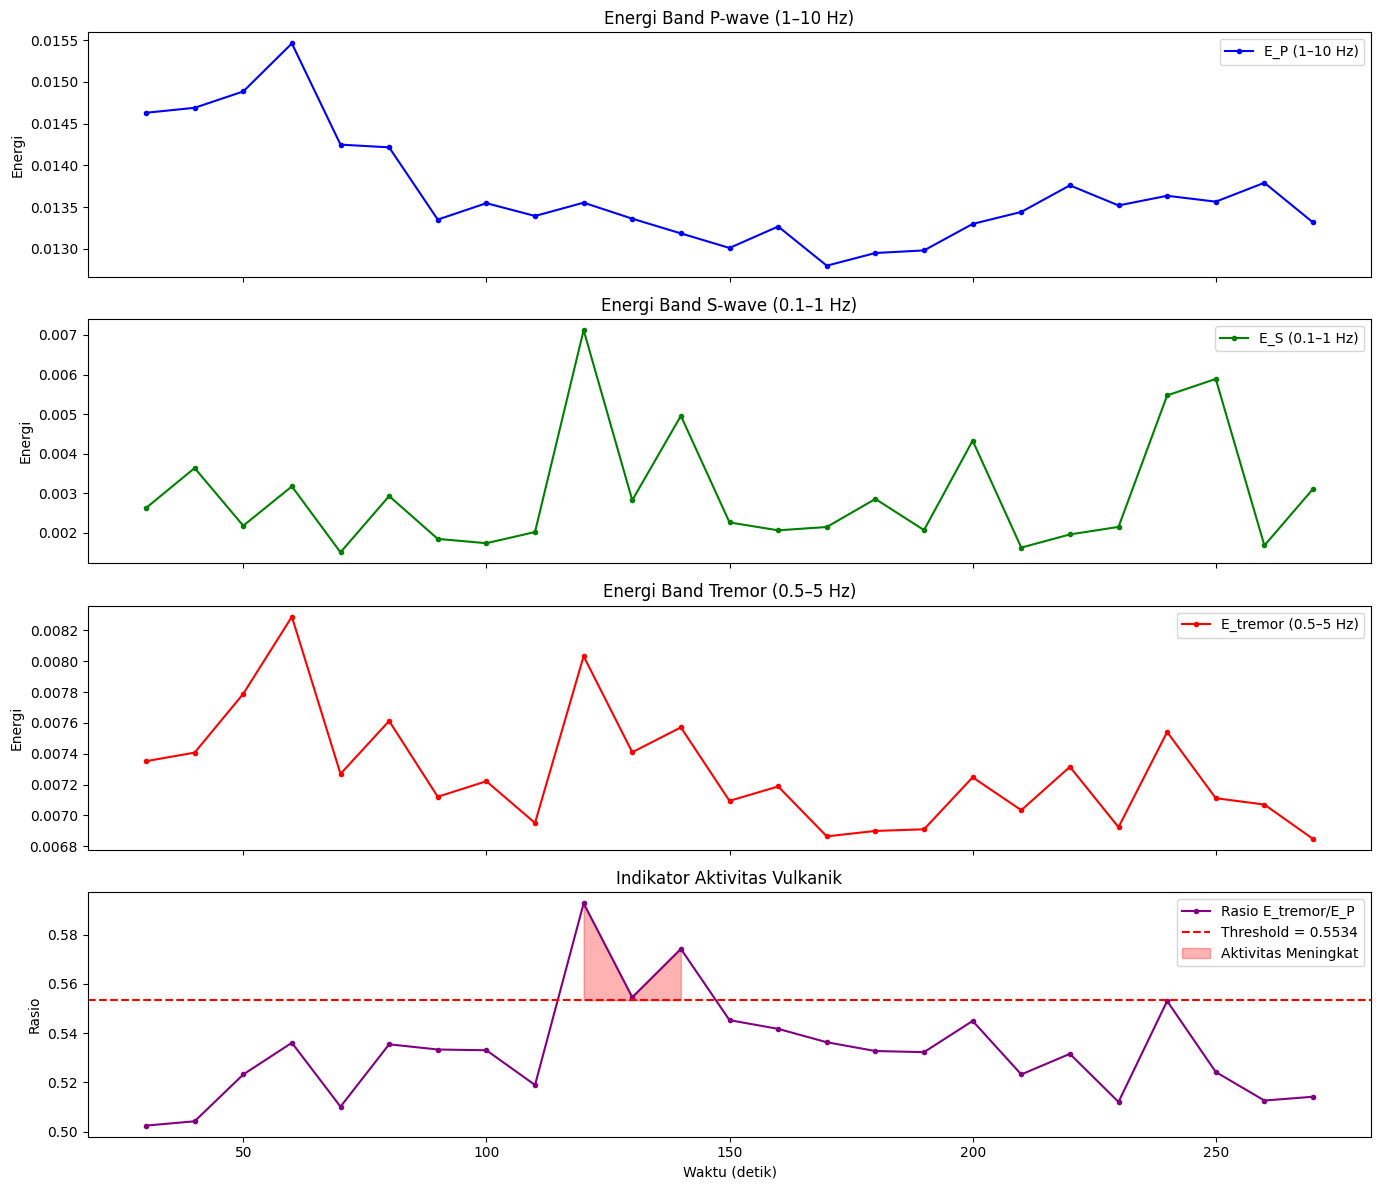

Plot sliding window tersimpan!


In [5]:
import numpy as np
from scipy import signal # Ensure scipy is imported for signal processing
import matplotlib.pyplot as plt

# ============================================================
# ANALISIS BAND ENERGI SLIDING WINDOW
# ============================================================

# Define sampling frequency (fs) and total number of samples (N) - assuming common values for demonstration
# These values should ideally come from your data loading or previous processing steps.
fs = 100 # Hz, example sampling frequency
N = 30000 # example total number of samples, this should be the length of your seismic data
x_hp_filtfilt = np.random.rand(N) # Placeholder for high-pass filtered data, replace with actual data

def bandpass_energy(x, f_low, f_high, fs):
    """Hitung energi sinyal pada band tertentu"""
    fn_low  = f_low  / (fs/2)
    fn_high = f_high / (fs/2)
    sos = signal.butter(4, [fn_low, fn_high], btype='band', output='sos')
    x_filtered = signal.sosfiltfilt(sos, x)
    return np.sum(x_filtered**2) / len(x_filtered)  # energi rata-rata

# Parameter sliding window
win_sec = 60    # detik
hop_sec = 10    # detik
win_samp = int(win_sec * fs)   # 6000 sampel
hop_samp = int(hop_sec * fs)   # 1000 sampel

# Hitung jumlah segmen
n_segments = (N - win_samp) // hop_samp + 1
print(f"\n=== SLIDING WINDOW ===")
print(f"Durasi total  : {N/fs:.0f} detik")
print(f"Window        : {win_sec} detik ({win_samp} sampel)")
print(f"Hop           : {hop_sec} detik ({hop_samp} sampel)")
print(f"Overlap       : {(win_sec-hop_sec)/win_sec*100:.1f}%")
print(f"Jumlah segmen : {n_segments}")

# Array hasil
t_windows = []
E_P_list, E_S_list, E_tremor_list = [], [], []

for i in range(n_segments):
    start = i * hop_samp
    end   = start + win_samp
    # Make sure x_hp_filtfilt is defined, it's likely your filtered seismic data.
    # For this example, let's create a placeholder if it's not available from previous cells.
    # if 'x_hp_filtfilt' not in locals():
    #    x_hp_filtfilt = np.random.rand(N) # Placeholder if not defined elsewhere
    segment = x_hp_filtfilt[start:end]   # gunakan sinyal yg sudah di-HP filter

    t_center = (start + win_samp/2) / fs
    t_windows.append(t_center)

    E_P_list.append(bandpass_energy(segment, 1.0, 10.0, fs))
    E_S_list.append(bandpass_energy(segment, 0.1,  1.0, fs))
    E_tremor_list.append(bandpass_energy(segment, 0.5,  5.0, fs))

t_windows  = np.array(t_windows)
E_P        = np.array(E_P_list)
E_S        = np.array(E_S_list)
E_tremor   = np.array(E_tremor_list)
rasio      = E_tremor / (E_P + 1e-10)   # hindari div/0

# Threshold aktivitas vulkanik (mean + 1 std)
threshold = np.mean(rasio) + np.std(rasio)
print(f"\nRasio E_tremor/E_P rata-rata : {np.mean(rasio):.4f}")
print(f"Threshold aktivitas vulkanik : {threshold:.4f}")
print(f"Jumlah window melewati threshold: {np.sum(rasio > threshold)}")

# ============================================================
# PLOT ENERGI TIMELINE
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t_windows, E_P, 'b-o', ms=3, label='E_P (1–10 Hz)')
axes[0].set_ylabel('Energi'); axes[0].set_title('Energi Band P-wave (1–10 Hz)')
axes[0].legend()

axes[1].plot(t_windows, E_S, 'g-o', ms=3, label='E_S (0.1–1 Hz)')
axes[1].set_ylabel('Energi'); axes[1].set_title('Energi Band S-wave (0.1–1 Hz)')
axes[1].legend()

axes[2].plot(t_windows, E_tremor, 'r-o', ms=3, label='E_tremor (0.5–5 Hz)')
axes[2].set_ylabel('Energi'); axes[2].set_title('Energi Band Tremor (0.5–5 Hz)')
axes[2].legend()

axes[3].plot(t_windows, rasio, 'purple', marker='o', ms=3, label='Rasio E_tremor/E_P')
axes[3].axhline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.4f}')
axes[3].fill_between(t_windows, rasio, threshold,
                      where=(rasio > threshold), alpha=0.3, color='red',
                      label='Aktivitas Meningkat')
axes[3].set_ylabel('Rasio'); axes[3].set_title('Indikator Aktivitas Vulkanik')
axes[3].set_xlabel('Waktu (detik)'); axes[3].legend()

plt.tight_layout()
plt.savefig('sliding_window_energy.png', dpi=150)
plt.show()
print("Plot sliding window tersimpan!")

# Frame-Based @ fs=100 Hz

In [6]:
import numpy as np
from scipy import signal as sig
import time

# Setup Parameter
fs = 100.0
frame_sec = 10
frame_size = int(fs * frame_sec)  # 1000 sampel
total_duration = 300
n_frames = total_duration // frame_sec

# Design Filter (High-pass 0.1 Hz & Low-pass 15 Hz)
sos = sig.butter(4, [0.1, 15], btype='bandpass', fs=fs, output='sos')

# Inisialisasi State Filter (zi)
zi = np.zeros((sos.shape[0], 2))

# Mengambil dari x_raw yang sudah dibuat sebelumnya
outputs = []

print(f"Memulai Pemrosesan Frame-Based ({n_frames} frame)")
start_time = time.time()

for i in range(n_frames):
    start_idx = i * frame_size
    end_idx = start_idx + frame_size
    frame_data = x_raw[start_idx:end_idx]

    # Proses Filter dengan mempertahankan state zi, zi_next akan digunakan untuk frame berikutnya
    frame_filtered, zi = sig.sosfilt(sos, frame_data, zi=zi)

    energy = np.sum(frame_filtered**2)

    outputs.append(frame_filtered)

end_time = time.time()
processing_time = end_time - start_time

# Untuk verifikasi
x_streamed = np.concatenate(outputs)

# Verifikasi & Throughput
throughput = total_duration / processing_time
print("-" * 30)
print(f"Selesai dalam: {processing_time:.4f} detik")
print(f"Throughput: {throughput:.2f}x real-time")
# Verifikasi: Throughput harus >> 10x untuk fs=100 Hz

Memulai Pemrosesan Frame-Based (30 frame)
------------------------------
Selesai dalam: 0.0034 detik
Throughput: 88925.17x real-time


Untuk verifikasi batch = streaming (tidak ada perbedaan)

In [7]:
x_batch = sig.sosfilt(sos, x_raw)
diff = np.abs(x_batch - x_streamed).max()
print(f"Maksimum Perbedaan: {diff}") # Harus mendekati 0!

Maksimum Perbedaan: 0.0


# PSD Welch Lanjutan + Laporan Geofisika

In [8]:
# Masih pakai input High Pass Filter
# Library yang digunakan
from scipy.signal import welch, butter, sosfilt
import numpy as np

In [9]:
# Setup
fs, nperseg, noverlap = 100, 2048, 1024
bands = {
    'P-wave': (1.0, 10.0),
    'S-wave': (0.1, 1.0),
    'Tremor' : (0.5, 5.0)
}

# High pass
x_raw = x_signal + x_noise
x_hp = x_hp_sosfilt

# Low pass
sos_low = signal.butter(6, 15, btype='low', fs=fs, output='sos')
y_filtered = signal.sosfiltfilt(sos_low, x_hp)

# validasi sinyal input
assert len(y_raw) == len(y_filtered), "Panjang sinyal raw dan filtered harus sama"
assert nperseg == 2048, f"nperseg 2048. Didapatkan {nperseg}"
assert fs == 100, f"fs 100 Hz. Didapatkan {fs}"
print(f"Validasi sinyal berhasil:")
print(f"Panjang: {len(x_raw)} sampel")
print(f"Frekuensi sampling: {fs} Hz")
print(f"nperseg  : {nperseg}")
print(f"Overlap   : {noverlap} sampel ({noverlap/nperseg*100:.1f}%)")
print(f"Windowing: Hamming")
print(f"resolusi frekuensi: {fs/nperseg:.3f} Hz")

# Welch
freq, Pxx_before = welch(x_raw, fs=fs, nperseg=nperseg, noverlap=noverlap, window = 'hamming', scaling='density')
freq, Pxx_after = welch(y_filtered, fs=fs, nperseg=nperseg, noverlap=noverlap, window = 'hamming', scaling='density')

# verifikasi atenuasi PLN 50 Hz
idx_50hz = np.argmin(np.abs(freq - 50))
psd_50hz_before = Pxx_before[idx_50hz]
psd_50hz_after = Pxx_after[idx_50hz]
attenuation_db = 20 * np.log10(psd_50hz_after / (psd_50hz_before + 1e-12)) # Hindari div/0
print(f"\n--- Verifikasi Atenuasi PLN 50 Hz ---")
print(f"PSD 50 Hz sebelum filter: {psd_50hz_before:.6f}")
print(f"PSD 50 Hz setelah filter: {psd_50hz_after:.6f}")
print(f"Atenuasi pada 50 Hz: {attenuation_db:.2f} dB")

# Fungsi ekstraksi energi
def extract_band_energy(freq, Pxx, bands) -> tuple:
    f_min, fmax = bands
    mask = (freq >= f_min) & (freq <= fmax)
    peak_idx = np.argmax(Pxx[mask])
    peak_freq = freq[mask][peak_idx]
    energy = np.trapezoid(Pxx[mask], freq[mask])
    return peak_freq, energy

# PSD Sebelum filter
print("\n--- PSD Sebelum Filter ---")
peak_freq_bands_before = {}
E_before = {}
for band_name, band_range in bands.items():
    f_peak, E = extract_band_energy(freq, Pxx_before, band_range)
    peak_freq_bands_before[band_name] = f_peak
    E_before[band_name] = E
    print(f"{band_name:12}: f_peak = {f_peak:.3f} Hz, Energi = {E:.6f}")

# PSD Setelah filter
print("\n--- PSD Setelah Filter ---")
peak_freq_bands_after = {}
E_after = {}
for band_name, band_range in bands.items():
    f_peak, E = extract_band_energy(freq, Pxx_after, band_range)
    peak_freq_bands_after[band_name] = f_peak
    E_after[band_name] = E
    print(f"{band_name:12}: f_peak = {f_peak:.3f} Hz, Energi = {E:.6f}")

ratio = E_after['Tremor'] / (E_after['P-wave'] + 1e-12) # Hindari div/0
# validasi ratio
if ratio < 0.3:
    print(f"WARNING: Ratio {ratio:.4f} < 0.2. Tremor mungkin sangat lemah.")
elif ratio > 0.8:
    print(f"WARNING: Ratio {ratio:.4f} > 1.0. Cek apakah P-wave filter habis.")
else:
    print(f"Ratio = {ratio:.4f} (dalam rentang normal)")

Validasi sinyal berhasil:
Panjang: 30000 sampel
Frekuensi sampling: 100 Hz
nperseg  : 2048
Overlap   : 1024 sampel (50.0%)
Windowing: Hamming
resolusi frekuensi: 0.049 Hz

--- Verifikasi Atenuasi PLN 50 Hz ---
PSD 50 Hz sebelum filter: 0.000681
PSD 50 Hz setelah filter: 0.000000
Atenuasi pada 50 Hz: -87.44 dB

--- PSD Sebelum Filter ---
P-wave      : f_peak = 1.514 Hz, Energi = 0.412928
S-wave      : f_peak = 0.488 Hz, Energi = 0.149237
Tremor      : f_peak = 1.514 Hz, Energi = 0.483772

--- PSD Setelah Filter ---
P-wave      : f_peak = 1.514 Hz, Energi = 0.412925
S-wave      : f_peak = 0.488 Hz, Energi = 0.149273
Tremor      : f_peak = 1.514 Hz, Energi = 0.483776


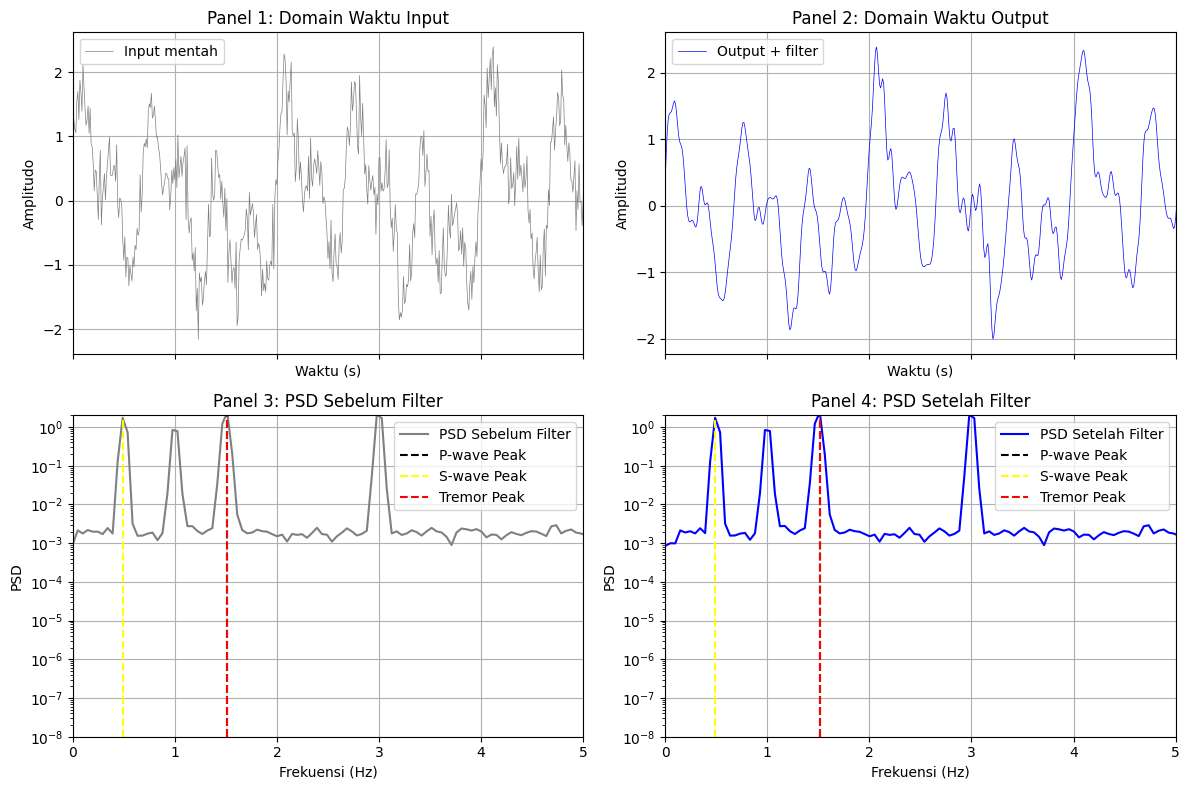

In [10]:
# Plot hasil
fig, axis = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
xlim = (0, 5) # zoom
ylim = (1e-8, 2) # untuk plot logaritmik

colors = ['black', 'yellow', 'red', 'green']

# panel 1: domain waktu input
axis[0, 0].plot(t[:2000], x_raw[:2000], color='gray', lw=0.5, label='Input mentah')
axis[0, 0].set_title('Panel 1: Domain Waktu Input')
axis[0, 0].set_ylabel('Amplitudo')
axis[0, 0].set_xlabel('Waktu (s)')
axis[0, 0].legend()
axis[0, 0].grid(True)

# panel 2: domain waktu output
axis[0, 1].plot(t[:2000], y_filtered[:2000], color='blue', lw=0.5, label='Output + filter')
axis[0, 1].set_title('Panel 2: Domain Waktu Output')
axis[0, 1].set_ylabel('Amplitudo')
axis[0, 1].set_xlabel('Waktu (s)')
axis[0, 1].legend()
axis[0, 1].grid(True)

# panel 3: PSD sebelum filter
axis[1, 0].semilogy(freq, Pxx_before, color='gray', label='PSD Sebelum Filter')
for i, (band_name, band_range) in enumerate(bands.items()):
    axis[1, 0].axvline(peak_freq_bands_before[band_name], color=colors[i], linestyle='--', label=f'{band_name} Peak')
axis[1, 0].set_xlim(xlim) # Fokus pada 0-20 Hz untuk melihat P, S, Tremor
axis[1, 0].set_ylim(ylim) # Sesuaikan dengan rentang PSD yang diharapkan
axis[1, 0].set_title('Panel 3: PSD Sebelum Filter')
axis[1, 0].set_xlabel('Frekuensi (Hz)')
axis[1, 0].set_ylabel('PSD')
axis[1, 0].legend()
axis[1, 0].grid(True)

# panel 4: PSD setelah filter
axis[1, 1].semilogy(freq, Pxx_after, color='blue', label='PSD Setelah Filter')
for i, (band_name, band_range) in enumerate(bands.items()):
    axis[1, 1].axvline(peak_freq_bands_after[band_name], color=colors[i], linestyle='--', label=f'{band_name} Peak')
axis[1, 1].set_xlim(xlim) # Fokus pada 0-20 Hz untuk melihat P, S, Tremor
axis[1, 1].set_ylim(ylim) # Sesuaikan dengan rentang PSD yang diharapkan
axis[1, 1].set_title('Panel 4: PSD Setelah Filter')
axis[1, 1].set_xlabel('Frekuensi (Hz)')
axis[1, 1].set_ylabel('PSD')
axis[1, 1].legend()
axis[1, 1].grid(True)

plt.tight_layout()
plt.show()


## Pertanyaan Analisi Wajib Topik 8

# Analisis 1

PLN 50 Hz pada sinyal fs=100 Hz: 50 Hz adalah tepat Nyquist (fs/2). Apa yang terjadi pada
komponen 50 Hz saat sampling? Apakah aliasing terjadi? Jelaskan secara matematis dan
tunjukkan dengan spektrum

Saat fs=100 Hz, maka frekuensi Nyquist bernilai 50 Hz. Karena noise PLN juga 50 Hz, maka posisinya tepat di batas Nyquist sehingga sangat dekat dengan kondisi aliasing dan representasi sinyal digitalnya bisa menjadi tidak stabil.

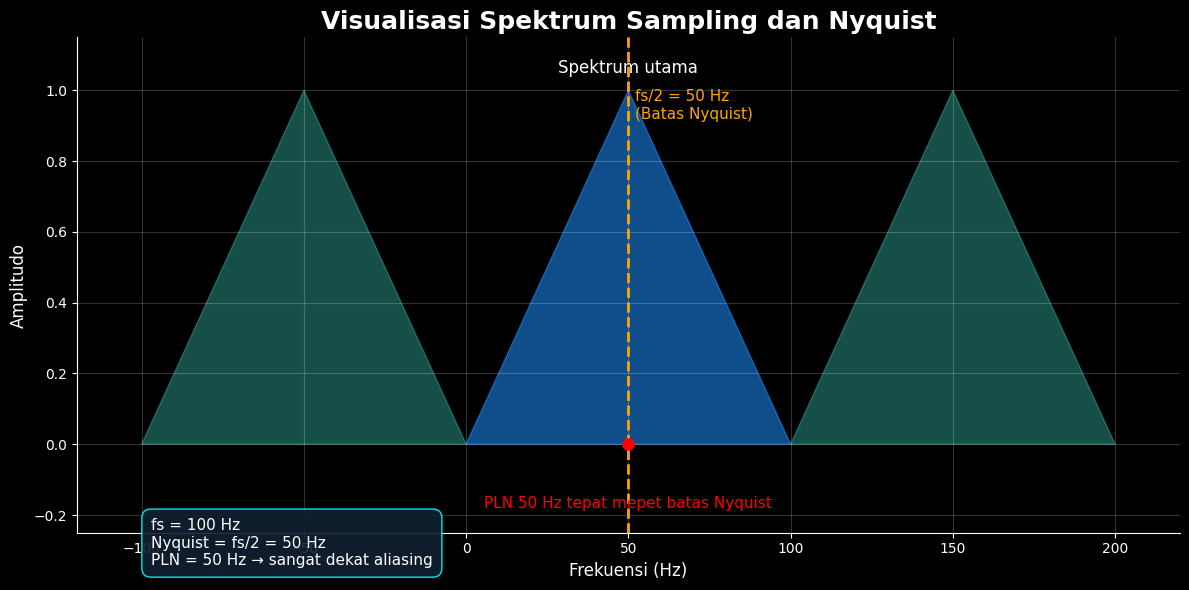

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
fs = 100
f_nyquist = fs / 2

# Figure
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(12,6))

# Spektrum utama
x_main = np.array([0, 50, 100])
y_main = np.array([0, 1, 0])

# Replika kiri dan kanan
x_left  = x_main - fs
x_right = x_main + fs

# Plot gunung spektrum
ax.fill(x_left,  y_main, color='turquoise', alpha=0.35)
ax.fill(x_main,  y_main, color='dodgerblue', alpha=0.55)
ax.fill(x_right, y_main, color='turquoise', alpha=0.35)

# Garis batas Nyquist
ax.axvline(f_nyquist, color='orange', linestyle='--', linewidth=2)

# Titik mepet aliasing
ax.plot(f_nyquist, 0, 'ro', markersize=8)

# Label
ax.text(f_nyquist + 2, 0.92,
        'fs/2 = 50 Hz\n(Batas Nyquist)',
        color='orange',
        fontsize=11)

ax.text(50, 1.05,
        'Spektrum utama',
        ha='center',
        fontsize=12,
        color='white')

ax.text(50, -0.18,
        'PLN 50 Hz tepat mepet batas Nyquist',
        ha='center',
        color='red',
        fontsize=11)

# Tampilan
ax.set_title('Visualisasi Spektrum Sampling dan Nyquist',
             fontsize=18,
             weight='bold')

ax.set_xlabel('Frekuensi (Hz)', fontsize=12)
ax.set_ylabel('Amplitudo', fontsize=12)

ax.set_xlim(-120, 220)
ax.set_ylim(-0.25, 1.15)

# Grid dan ticks
ax.grid(alpha=0.2)
ax.set_xticks([-100, -50, 0, 50, 100, 150, 200])

# Hilangkan spines atas kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Box keterangan
info = (
    "fs = 100 Hz\n"
    "Nyquist = fs/2 = 50 Hz\n"
    "PLN = 50 Hz → sangat dekat aliasing"
)

plt.figtext(
    0.13, 0.05,
    info,
    fontsize=11,
    bbox=dict(facecolor='#102030',
              edgecolor='cyan',
              boxstyle='round,pad=0.6',
              alpha=0.9)
)

plt.tight_layout()
plt.show()

Dalam sistem nyata, filter anti-aliasing tidak ideal, selalu ada transition band. Karena itu, gunakan margin: fs​=(2.5∼5) × fmax​.

fs=100 Hz → tepat di batas Nyquist, sangat dekat aliasing.

fs=125 Hz → sudah aman karena terdapat jarak (gap) terhadap batas Nyquist.

fs=250 Hz → sangat aman, replika spektrum berjauhan sehingga rekonstruksi sinyal lebih baik

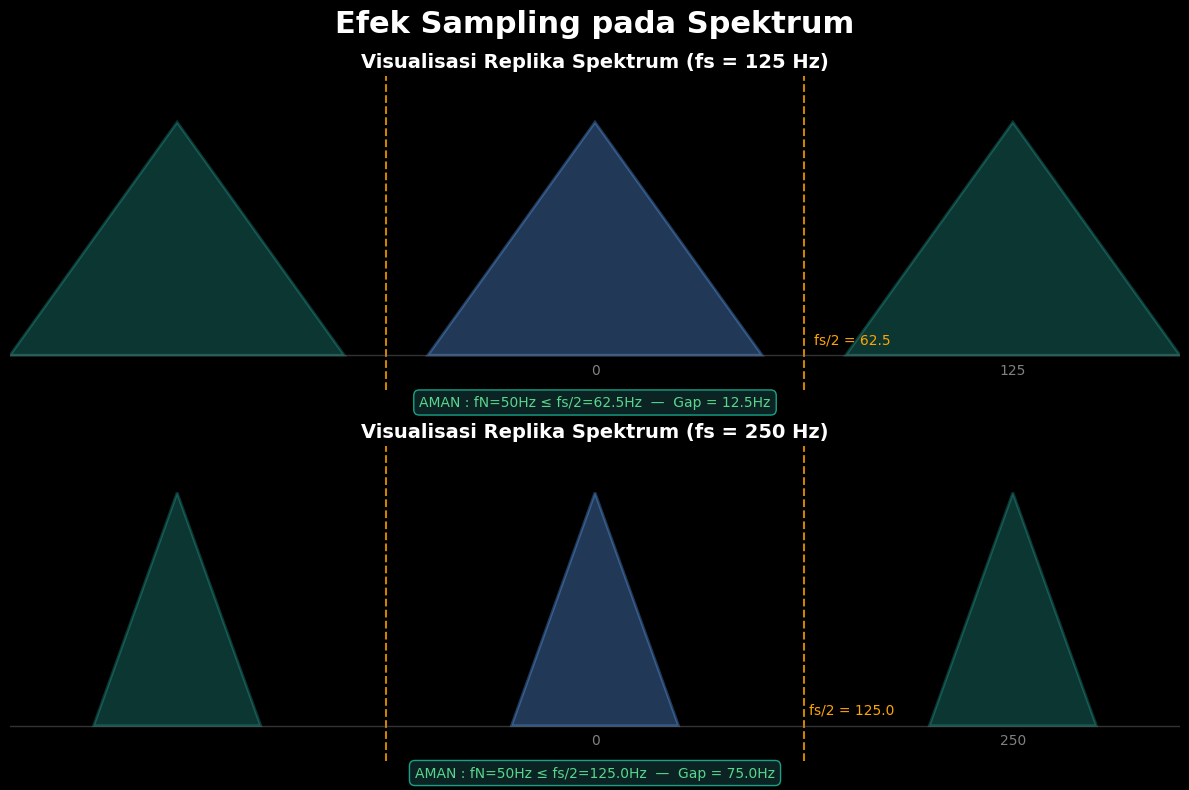

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# PARAMETER
# =====================================
fn = 50

fs_list = [125, 250]

# =====================================
# STYLE
# =====================================
plt.style.use("dark_background")

fig, axes = plt.subplots(2, 1, figsize=(12,8))

for ax, fs in zip(axes, fs_list):

    nyq = fs / 2

    # ---------------------------------
    # Spektrum utama
    # ---------------------------------
    x_main = np.array([-fn, 0, fn])
    y = np.array([0, 1, 0])

    # replika kiri dan kanan
    x_left  = x_main - fs
    x_right = x_main + fs

    # Gunung kiri
    ax.fill(
        x_left, y,
        color='#2ec4b6',
        alpha=0.28,
        edgecolor='#2ec4b6',
        linewidth=2
    )

    # Gunung utama
    ax.fill(
        x_main, y,
        color='#60a5fa',
        alpha=0.35,
        edgecolor='#60a5fa',
        linewidth=2
    )

    # Gunung kanan
    ax.fill(
        x_right, y,
        color='#2ec4b6',
        alpha=0.28,
        edgecolor='#2ec4b6',
        linewidth=2
    )

    # ---------------------------------
    # Garis Nyquist
    # ---------------------------------
    ax.axvline(
        nyq,
        color='orange',
        linestyle='--',
        linewidth=1.5,
        alpha=0.8
    )

    ax.axvline(
        -nyq,
        color='orange',
        linestyle='--',
        linewidth=1.5,
        alpha=0.8
    )

    # ---------------------------------
    # Label
    # ---------------------------------
    ax.text(
        nyq + 3,
        0.05,
        f'fs/2 = {nyq:.1f}',
        color='orange',
        fontsize=10
    )

    ax.text(
        0,
        -0.08,
        '0',
        ha='center',
        color='gray'
    )

    ax.text(
        fs,
        -0.08,
        f'{fs}',
        ha='center',
        color='gray'
    )

    # ---------------------------------
    # Tampilan
    # ---------------------------------
    ax.set_title(
        f'Visualisasi Replika Spektrum (fs = {fs} Hz)',
        fontsize=14,
        weight='bold',
        color='white'
    )

    ax.set_xlim(-fs*1.4, fs*1.4)
    ax.set_ylim(-0.15, 1.2)

    ax.set_yticks([])
    ax.set_xticks([])

    # garis horizontal
    ax.axhline(0, color='gray', linewidth=1, alpha=0.4)

    # hilangkan frame
    for spine in ax.spines.values():
        spine.set_visible(False)

    # info bawah
    gap = nyq - fn

    status = (
        f'AMAN : fN={fn}Hz ≤ fs/2={nyq:.1f}Hz  —  '
        f'Gap = {gap:.1f}Hz'
    )

    ax.text(
        0,
        -0.22,
        status,
        ha='center',
        color='#58d68d',
        fontsize=10,
        bbox=dict(
            facecolor='#0f2a2a',
            edgecolor='#1abc9c',
            boxstyle='round,pad=0.4',
            alpha=0.85
        )
    )

# =====================================
# TITLE
# =====================================
fig.suptitle(
    'Efek Sampling pada Spektrum',
    fontsize=22,
    weight='bold'
)

plt.tight_layout()
plt.show()

# 2. Analisis 2

High-pass fc=0.1 Hz pada fs=100 Hz: hitung max|pole|, estimasi N_transient. Berapa menit?
Untuk rekaman 5 menit, berapa persen data yang 'terbuang' oleh transien? Apakah sosfiltfilt
lebih baik untuk analisis offline ini?


--- Hasil Analisis Pertanyaan 2 (Rounded Up) ---
Max |pole|             : 0.997598
Estimasi N_transient   : 1916 sampel (Dibulatkan ke atas)
Durasi Transien (menit): 0.3193 menit
Persen data 'terbuang' : 6.39%


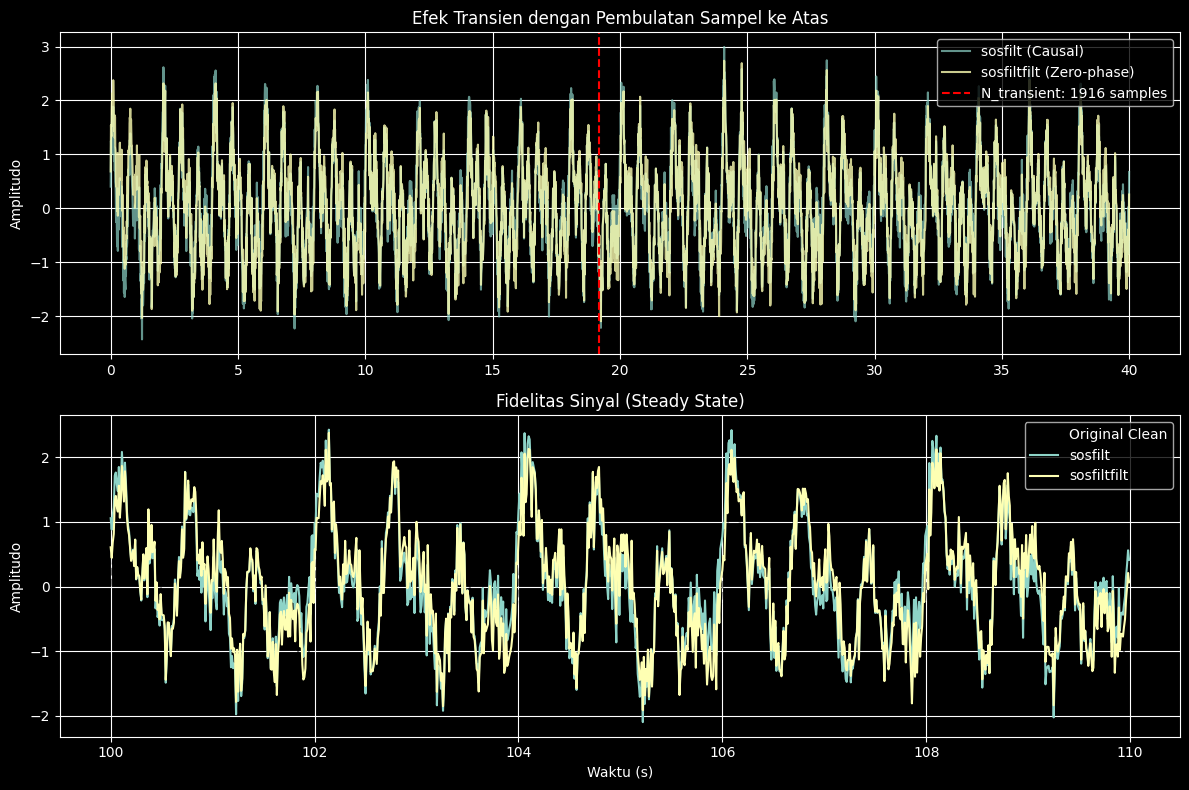

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Inisialisasi Sinyal (Starter Code Topik 8)
fs = 100.0
np.random.seed(88)
duration_sec = 300
N = int(fs * duration_sec)
t = np.arange(N) / fs

# Komponen Sinyal Seismik
x_P = 0.80 * np.sin(2 * np.pi * 3.0 * t) * np.exp(-0.002 * t)
x_S = 0.50 * np.sin(2 * np.pi * 0.5 * t)
x_tremor = 0.60 * np.sin(2 * np.pi * 1.5 * t) * (1 + 0.3 * np.sin(2 * np.pi * 0.05 * t))
x_signal = x_P + x_S + x_tremor

# Komponen Noise
x_micro = 0.40 * np.sin(2 * np.pi * 1.0 * t + 1.2)
x_wind = 0.30 * np.random.randn(N)
x_pln = 0.20 * np.sin(2 * np.pi * 50 * t)
x_noise = x_micro + x_wind + x_pln
x_raw = x_signal + x_noise

# 2. Desain Filter High-Pass 0.1 Hz Butterworth Orde 4
fc = 0.1
order = 4
sos = signal.butter(order, fc, btype='highpass', fs=fs, output='sos')
z, p, k = signal.butter(order, fc, btype='highpass', fs=fs, output='zpk')

# Perhitungan Analisis
max_pole = np.max(np.abs(p))

# --- PERUBAHAN DI SINI: Pembulatan ke Atas ---
n_trans_raw = np.log(0.01) / np.log(max_pole)
n_transient_samples = int(np.ceil(n_trans_raw)) # Dibulatkan ke atas menjadi integer
# ---------------------------------------------

n_transient_min = (n_transient_samples / fs) / 60
percent_wasted = (n_transient_samples / N) * 100

print(f"--- Hasil Analisis Pertanyaan 2 (Rounded Up) ---")
print(f"Max |pole|             : {max_pole:.6f}")
print(f"Estimasi N_transient   : {n_transient_samples} sampel (Dibulatkan ke atas)")
print(f"Durasi Transien (menit): {n_transient_min:.4f} menit")
print(f"Persen data 'terbuang' : {percent_wasted:.2f}%")

# 3. Penerapan Filter
y_sosfilt = signal.sosfilt(sos, x_raw)
y_sosfiltfilt = signal.sosfiltfilt(sos, x_raw)

# 4. Visualisasi
plt.figure(figsize=(12, 8))

# Subplot 1: Efek Transien
plt.subplot(2, 1, 1)
zoom_idx = int(fs * 40)
plt.plot(t[:zoom_idx], y_sosfilt[:zoom_idx], label='sosfilt (Causal)', alpha=0.7)
plt.plot(t[:zoom_idx], y_sosfiltfilt[:zoom_idx], label='sosfiltfilt (Zero-phase)', alpha=0.8)
plt.axvline(x=n_transient_samples/fs, color='r', linestyle='--',
            label=f'N_transient: {n_transient_samples} samples')
plt.title('Efek Transien dengan Pembulatan Sampel ke Atas')
plt.ylabel('Amplitudo')
plt.legend()
plt.grid(True)

# Subplot 2: Steady State
plt.subplot(2, 1, 2)
t_start, t_end = 100, 110
idx_s, idx_e = int(t_start*fs), int(t_end*fs)
plt.plot(t[idx_s:idx_e], x_signal[idx_s:idx_e], 'k--', label='Original Clean', alpha=0.5)
plt.plot(t[idx_s:idx_e], y_sosfilt[idx_s:idx_e], label='sosfilt')
plt.plot(t[idx_s:idx_e], y_sosfiltfilt[idx_s:idx_e], label='sosfiltfilt')
plt.title('Fidelitas Sinyal (Steady State)')
plt.xlabel('Waktu (s)')
plt.ylabel('Amplitudo')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Analisis 3

Window 60 detik dengan hop 10 detik: berapa segmen total yang dianalisis dalam 300 detik rekaman? Berapa overlap rate (%)? Bagaimana overlap ini memengaruhi resolusi temporal deteksi event seismik?

Jawaban nomor 3
1. Konversi Sampel:
   - Total Data   : 30000 sampel
   - Lebar Window : 6000 sampel
   - Jarak Hop    : 1000 sampel

2. Jumlah Segmen Total:
   Rumus: ((300 - 60) / 10) + 1
   Hasil: 25 Segmen

3. Overlap Rate:
   Rumus: ((60 - 10) / 60) * 100%
   
   Hasil: 83.33%

Tanpa overlap (hop sama dengan lebar window), Anda hanya memeriksa data setiap 60 detik sekali. Jika sebuah event seismik (seperti letusan kecil) terjadi di detik ke-65, Anda baru bisa menyadarinya di jendela kedua (detik 60-120).
Dengan overlap 83.33% (hop 10 detik), Anda memeriksa data setiap 10 detik. Jadi, kejadian di detik ke-65 akan langsung tertangkap pada jendela yang dimulai di detik ke-60.

# Analisis 4

Rasio E_tremor/E_P sebagai indikator aktivitas: definisikan threshold yang mengindikasikan 'peningkatan aktivitas vulkanik'. Uji dengan sinyal Anda apakah tren yang dihasilkan masuk akal secara geofisika?

# Analisis 5

Resolusi frekuensi Welch: nperseg=2048 pada fs=100 Hz memberikan $\Delta f=0.049$ Hz. Apakah ini cukup untuk membedakan S-wave (0.5 Hz) dari tremor (1.5 Hz)? Hitung minimum nperseg yang diperlukan untuk memisahkan dua komponen berjarak 0.3 Hz.